# Future downside-target audit

This notebook audits the stock-quarter outcomes produced by `scripts/13_build_downside_targets.py`.

It checks:

1. one-to-one coverage of the prediction universe;
2. strict separation between the information date and future target window;
3. implementation of the 63-market-day horizon and usability rule;
4. reconciliation with the saved quarterly audit; and
5. coverage, distributions, and economic relationships among the outcomes.

The primary target is the positive magnitude of maximum drawdown over the next 63 market days. The notebook reads saved outputs only and does not rebuild them.

## 1. Setup and inputs

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import pyarrow.parquet as pq


project_root = Path.cwd().resolve()

while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


paths = get_paths_config()
targets_path = paths.interim / "crsp" / "downside_targets.parquet"
audit_path = paths.interim / "crsp" / "target_construction_audit.parquet"
daily_path = paths.raw / "crsp" / "daily_stock.parquet"
security_nodes_path = (
    paths.interim / "networks" / "ownership" / "security_nodes.parquet"
)

table_paths = {
    "downside_targets": targets_path,
    "target_construction_audit": audit_path,
    "security_nodes": security_nodes_path,
}

for name, path in {**table_paths, "daily_stock": daily_path}.items():
    if not path.is_file():
        raise FileNotFoundError(f"Required {name} file not found: {path}")

inventory = pd.DataFrame(
    {
        "table": table_paths.keys(),
        "rows": [
            pq.ParquetFile(path).metadata.num_rows
            for path in table_paths.values()
        ],
    }
)

connection = duckdb.connect(database=":memory:")
connection.read_parquet(str(targets_path)).create_view("targets")
connection.read_parquet(str(audit_path)).create_view("saved_audit")
connection.read_parquet(str(security_nodes_path)).create_view("security_nodes")
connection.read_parquet(str(daily_path)).create_view("daily_stock")
connection.execute(
    '''
    CREATE TEMP TABLE market_calendar AS
    SELECT dlycaldt, ROW_NUMBER() OVER (ORDER BY dlycaldt) AS market_day
    FROM (SELECT DISTINCT dlycaldt FROM daily_stock)
    '''
)

display(inventory.style.format({"rows": "{:,}"}))

,table,rows
0,downside_targets,"206,868"
1,target_construction_audit,52
2,security_nodes,"206,868"


## 2. Target integrity and timing

Each security node should have exactly one target row. A complete target window begins after the information date and contains exactly 63 market days. A target is usable with at least 50 observed returns, or with an observed delisting return, provided the common horizon is complete.

In [2]:
check_values = connection.execute(
    '''
    WITH target_checks AS (
        SELECT
            COUNT(*) - COUNT(DISTINCT (t.report_period, t.permno))
                AS duplicate_target_keys,
            COUNT(*) FILTER (
                WHERE t.report_period IS NULL
                   OR t.information_date IS NULL
                   OR t.permno IS NULL
            ) AS missing_target_keys,
            COUNT(*) FILTER (
                WHERE TRY_STRPTIME(t.PERIODOFREPORT, '%d-%b-%Y') IS NULL
                   OR TRY_STRPTIME(t.PERIODOFREPORT, '%d-%b-%Y')::DATE
                        != CAST(t.report_period AS DATE)
            ) AS inconsistent_report_periods,
            COUNT(*) FILTER (WHERE t.target_horizon_market_days != 63)
                AS incorrect_horizon_labels,
            COUNT(*) FILTER (
                WHERE t.target_window_start IS NULL
                   OR t.target_window_start <= t.information_date
                   OR (t.target_window_end IS NOT NULL
                       AND t.target_window_end < t.target_window_start)
            ) AS invalid_window_dates,
            COUNT(*) FILTER (
                WHERE t.target_window_complete
                  AND (s.market_day IS NULL
                       OR e.market_day IS NULL
                       OR e.market_day - s.market_day != 62)
            ) AS incorrect_market_day_horizons,
            COUNT(*) FILTER (
                WHERE t.target_window_complete IS DISTINCT FROM
                    (t.target_window_end IS NOT NULL)
            ) AS incorrect_window_flags,
            COUNT(*) FILTER (
                WHERE t.return_observations_63d NOT BETWEEN 0 AND 63
                   OR (t.future_max_drawdown_63d IS NOT NULL
                       AND NOT t.future_max_drawdown_63d BETWEEN 0 AND 1)
                   OR (t.future_downside_volatility_63d IS NOT NULL
                       AND t.future_downside_volatility_63d < 0)
            ) AS invalid_target_values,
            COUNT(*) FILTER (
                WHERE t.delisting_return_observed AND NOT t.delisted_in_window
            ) AS invalid_delisting_flags,
            COUNT(*) FILTER (
                WHERE t.target_usable IS DISTINCT FROM (
                    t.target_window_complete
                    AND (NOT t.delisted_in_window
                         OR t.delisting_return_observed)
                    AND (t.return_observations_63d >= 50
                         OR t.delisting_return_observed)
                    AND t.future_max_drawdown_63d IS NOT NULL
                )
            ) AS incorrect_usability_flags
        FROM targets t
        LEFT JOIN market_calendar s
            ON t.target_window_start = s.dlycaldt
        LEFT JOIN market_calendar e
            ON t.target_window_end = e.dlycaldt
    ),
    coverage_checks AS (
        SELECT
            COUNT(*) FILTER (WHERE t.permno IS NULL) AS nodes_without_targets,
            COUNT(*) FILTER (WHERE n.permno IS NULL) AS targets_without_nodes
        FROM (SELECT report_period, permno FROM security_nodes) n
        FULL JOIN (SELECT report_period, permno FROM targets) t
            USING (report_period, permno)
    )
    SELECT * FROM target_checks CROSS JOIN coverage_checks
    '''
).fetchdf().iloc[0]

integrity_checks = pd.DataFrame(
    {
        "check": check_values.index.str.replace("_", " "),
        "violations": check_values.values,
    }
)

display(integrity_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total target-integrity violations: {integrity_checks['violations'].sum():,}")

,check,violations
0,duplicate target keys,0
1,missing target keys,0
2,inconsistent report periods,0
3,incorrect horizon labels,0
4,invalid window dates,0
5,incorrect market day horizons,0
6,incorrect window flags,0
7,invalid target values,0
8,invalid delisting flags,0
9,incorrect usability flags,0



Total target-integrity violations: 0


## 3. Coverage and quarterly reconciliation

Unavailable targets remain in the table with explicit flags. Delisting cases are usable only when the delisting return is observed. The saved quarterly audit should reproduce the target table exactly. Unavailability reasons may overlap and therefore should not be added together.

In [3]:
availability = connection.execute(
    '''
    SELECT
        COUNT(*) AS stock_quarters,
        COUNT(*) FILTER (WHERE target_window_complete)
            AS complete_horizon_stock_quarters,
        COUNT(*) FILTER (WHERE target_usable) AS usable_stock_quarters,
        AVG(CAST(target_usable AS DOUBLE)) AS usable_share,
        COUNT(*) FILTER (WHERE delisted_in_window) AS delisting_events,
        COUNT(*) FILTER (WHERE delisting_return_observed)
            AS observed_delisting_returns,
        COUNT(*) FILTER (
            WHERE delisted_in_window AND NOT delisting_return_observed
        ) AS missing_delisting_returns
    FROM targets
    '''
).fetchdf()

unavailable_reasons = connection.execute(
    '''
    SELECT
        COUNT(*) FILTER (WHERE NOT target_window_complete)
            AS incomplete_common_horizon,
        COUNT(*) FILTER (
            WHERE target_window_complete
              AND return_observations_63d < 50
              AND NOT delisting_return_observed
        ) AS insufficient_returns,
        COUNT(*) FILTER (
            WHERE delisted_in_window AND NOT delisting_return_observed
        ) AS missing_delisting_return
    FROM targets
    '''
).fetchdf().T.reset_index()
unavailable_reasons.columns = ["reason", "stock_quarters"]

audit_reconciliation = connection.execute(
    '''
    WITH calculated AS (
        SELECT
            PERIODOFREPORT, report_period, information_date,
            COUNT(*) AS security_periods,
            COUNT(*) FILTER (WHERE target_window_complete)
                AS complete_horizon_security_periods,
            COUNT(*) FILTER (WHERE target_usable) AS usable_security_periods,
            AVG(CAST(target_usable AS DOUBLE)) AS usable_share,
            MEDIAN(return_observations_63d) AS median_return_observations_63d,
            COUNT(*) FILTER (WHERE delisted_in_window) AS delisting_events,
            COUNT(*) FILTER (
                WHERE delisted_in_window AND NOT delisting_return_observed
            ) AS missing_delisting_returns,
            MEDIAN(future_max_drawdown_63d) FILTER (WHERE target_usable)
                AS median_future_max_drawdown_63d
        FROM targets
        GROUP BY PERIODOFREPORT, report_period, information_date
    )
    SELECT
        (SELECT COUNT(*) - COUNT(DISTINCT report_period) FROM saved_audit)
            AS duplicate_audit_quarters,
        COUNT(*) FILTER (WHERE c.report_period IS NULL)
            AS audits_without_targets,
        COUNT(*) FILTER (WHERE a.report_period IS NULL)
            AS target_quarters_without_audits,
        COUNT(*) FILTER (
            WHERE a.PERIODOFREPORT != c.PERIODOFREPORT
               OR a.information_date != c.information_date
               OR a.security_periods != c.security_periods
               OR a.complete_horizon_security_periods
                    != c.complete_horizon_security_periods
               OR a.usable_security_periods != c.usable_security_periods
               OR abs(a.usable_share - c.usable_share) > 1e-12
               OR a.median_return_observations_63d
                    != c.median_return_observations_63d
               OR a.delisting_events != c.delisting_events
               OR a.missing_delisting_returns != c.missing_delisting_returns
               OR a.median_future_max_drawdown_63d
                    IS DISTINCT FROM c.median_future_max_drawdown_63d
        ) AS quarterly_statistic_mismatches
    FROM saved_audit a
    FULL JOIN calculated c USING (report_period)
    '''
).fetchdf().T.reset_index()
audit_reconciliation.columns = ["check", "violations"]

incomplete_quarters = connection.execute(
    '''
    SELECT
        report_period, information_date, security_periods,
        complete_horizon_security_periods, usable_security_periods
    FROM saved_audit
    WHERE complete_horizon_security_periods < security_periods
    ORDER BY report_period
    '''
).fetchdf()

display(availability.style.format({
    "stock_quarters": "{:,}",
    "complete_horizon_stock_quarters": "{:,}",
    "usable_stock_quarters": "{:,}",
    "usable_share": "{:.2%}",
    "delisting_events": "{:,}",
    "observed_delisting_returns": "{:,}",
    "missing_delisting_returns": "{:,}",
}))
display(unavailable_reasons.style.format({"stock_quarters": "{:,}"}))
display(audit_reconciliation.style.format({"violations": "{:,}"}))
display(incomplete_quarters.style.format({
    "security_periods": "{:,}",
    "complete_horizon_security_periods": "{:,}",
    "usable_security_periods": "{:,}",
}))

,stock_quarters,complete_horizon_stock_quarters,usable_stock_quarters,usable_share,delisting_events,observed_delisting_returns,missing_delisting_returns
0,"206,868","203,069","201,176",97.25%,"3,411","3,339",72


,reason,stock_quarters
0,incomplete_common_horizon,"3,799"
1,insufficient_returns,"1,881"
2,missing_delisting_return,72


,check,violations
0,duplicate_audit_quarters,0
1,audits_without_targets,0
2,target_quarters_without_audits,0
3,quarterly_statistic_mismatches,0


,report_period,information_date,security_periods,complete_horizon_security_periods,usable_security_periods
0,2026-03-31 00:00:00,2026-05-15 00:00:00,"3,799",0,0


## 4. Outcome distributions and relationships

Maximum drawdown and the loss measures use the intuitive convention that larger positive values indicate worse outcomes. Cumulative return remains signed. The saved worst-return fields are converted to positive loss magnitudes here for interpretation.

In [4]:
target_expressions = {
    "Maximum drawdown": "future_max_drawdown_63d",
    "Cumulative return": "future_cumulative_return_63d",
    "Downside volatility": "future_downside_volatility_63d",
    "Worst five-day loss": (
        "GREATEST(0.0, -future_worst_five_day_return_63d)"
    ),
    "Worst daily loss": "GREATEST(0.0, -future_worst_daily_return_63d)",
}
target_summaries = []

for target_name, expression in target_expressions.items():
    summary = connection.execute(
        f'''
        SELECT
            COUNT({expression}) AS observations,
            AVG({expression}) AS mean,
            QUANTILE_CONT({expression}, 0.01) AS p01,
            MEDIAN({expression}) AS median,
            QUANTILE_CONT({expression}, 0.99) AS p99
        FROM targets
        WHERE target_usable
        '''
    ).fetchdf().iloc[0].to_dict()
    target_summaries.append({"outcome": target_name, **summary})

target_distribution = pd.DataFrame(target_summaries)
relationships = connection.execute(
    '''
    SELECT
        CORR(future_max_drawdown_63d, future_cumulative_return_63d)
            AS cumulative_return,
        CORR(future_max_drawdown_63d, future_downside_volatility_63d)
            AS downside_volatility,
        CORR(
            future_max_drawdown_63d,
            GREATEST(0.0, -future_worst_five_day_return_63d)
        ) AS worst_five_day_loss
    FROM targets
    WHERE target_usable
    '''
).fetchdf().T.reset_index()
relationships.columns = ["outcome", "correlation_with_drawdown"]

cross_sectional_variation = connection.execute(
    '''
    WITH quarterly AS (
        SELECT
            report_period,
            COUNT(DISTINCT future_max_drawdown_63d) AS distinct_values,
            QUANTILE_CONT(future_max_drawdown_63d, 0.75)
                - QUANTILE_CONT(future_max_drawdown_63d, 0.25) AS iqr
        FROM targets
        WHERE target_usable
        GROUP BY report_period
    )
    SELECT
        COUNT(*) AS usable_quarters,
        MIN(distinct_values) AS minimum_distinct_target_values,
        MIN(iqr) AS minimum_within_quarter_iqr
    FROM quarterly
    '''
).fetchdf()

display(target_distribution.style.format({
    "observations": "{:,}",
    "mean": "{:.2%}",
    "p01": "{:.2%}",
    "median": "{:.2%}",
    "p99": "{:.2%}",
}))
display(relationships.style.format({
    "correlation_with_drawdown": "{:.3f}",
}))
display(cross_sectional_variation.style.format({
    "usable_quarters": "{:,}",
    "minimum_distinct_target_values": "{:,}",
    "minimum_within_quarter_iqr": "{:.2%}",
}))

,outcome,observations,mean,p01,median,p99
0,Maximum drawdown,"201,176.0",21.97%,0.70%,17.11%,77.77%
1,Cumulative return,"201,176.0",2.28%,-69.69%,0.82%,114.82%
2,Downside volatility,"201,176.0",34.17%,1.91%,26.44%,132.50%
3,Worst five-day loss,"201,176.0",13.90%,0.46%,10.73%,58.06%
4,Worst daily loss,"201,176.0",9.07%,0.48%,6.56%,45.32%


,outcome,correlation_with_drawdown
0,cumulative_return,-0.367
1,downside_volatility,0.856
2,worst_five_day_loss,0.912


,usable_quarters,minimum_distinct_target_values,minimum_within_quarter_iqr
0,51,"3,717",10.53%


## 5. Primary-target distribution

The histogram shows the full cross-sectional distribution of the usable maximum-drawdown target.

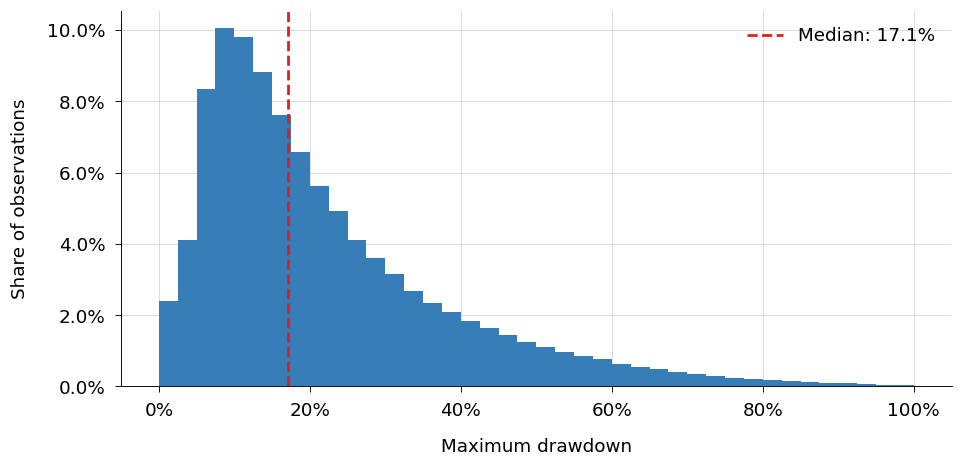

In [5]:
drawdowns = connection.execute(
    '''
    SELECT future_max_drawdown_63d
    FROM targets
    WHERE target_usable
    '''
).fetchdf()["future_max_drawdown_63d"]
median_drawdown = drawdowns.median()

set_matplotlib_style()
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.hist(
    drawdowns,
    color=COLOR_PALETTE[0],
    bins=np.linspace(0, 1, 41),
    weights=np.ones(len(drawdowns)) / len(drawdowns),
)
axis.axvline(
    median_drawdown,
    color=COLOR_PALETTE[1],
    linestyle="--",
    label=f"Median: {median_drawdown:.1%}",
)
#axis.set_title("Distribution of forward 63-day maximum drawdown")
axis.set_xlabel("Maximum drawdown")
axis.set_ylabel("Share of observations")
axis.xaxis.set_major_formatter(PercentFormatter(1.0))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "03_01_target_distribution_histogram.pdf")
plt.show()

## 6. Variation through time

The median describes the typical stock, while the 90th percentile shows the more fragile part of each quarterly cross-section.

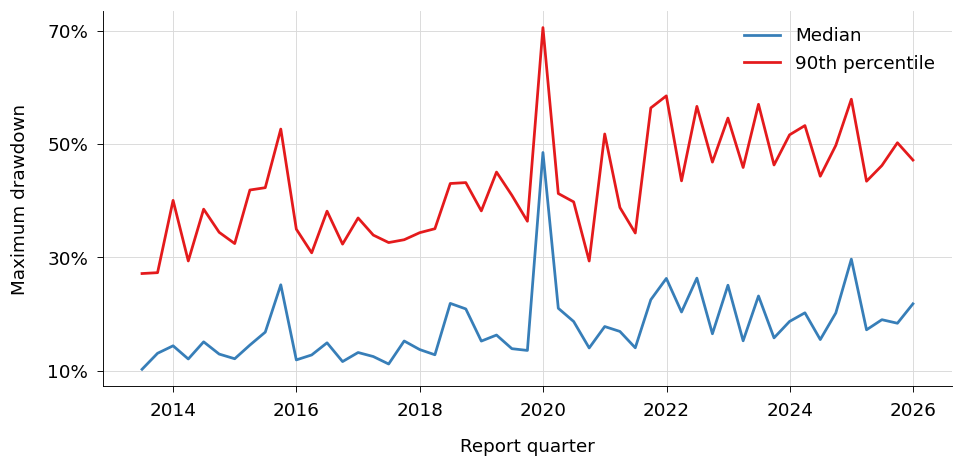

,report_period,usable_stock_quarters,median_drawdown,p90_drawdown
26,2019-12-31 00:00:00,"3,724",48.49%,70.54%
46,2024-12-31 00:00:00,"3,911",29.66%,57.89%
36,2022-06-30 00:00:00,"4,562",26.31%,56.63%
34,2021-12-31 00:00:00,"4,527",26.26%,58.49%
9,2015-09-30 00:00:00,"3,921",25.13%,52.62%


In [6]:
import numpy as np

quarterly_targets = connection.execute(
    '''
    SELECT
        report_period,
        COUNT(*) AS usable_stock_quarters,
        MEDIAN(future_max_drawdown_63d) AS median_drawdown,
        QUANTILE_CONT(future_max_drawdown_63d, 0.90) AS p90_drawdown
    FROM targets
    WHERE target_usable
    GROUP BY report_period
    ORDER BY report_period
    '''
).fetchdf()

set_matplotlib_style()
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    quarterly_targets["report_period"],
    quarterly_targets["median_drawdown"],
    label="Median",
)
axis.plot(
    quarterly_targets["report_period"],
    quarterly_targets["p90_drawdown"],
    label="90th percentile",
)
#axis.set_title("Forward 63-day maximum drawdown by quarter")
axis.set_xlabel("Report quarter")
axis.set_ylabel("Maximum drawdown")
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.set_yticks(np.arange(0.1, 0.8, 0.2))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "03_01_target_by_quarter.pdf")
plt.show()

display(
    quarterly_targets.nlargest(5, "median_drawdown").style.format({
        "usable_stock_quarters": "{:,}",
        "median_drawdown": "{:.2%}",
        "p90_drawdown": "{:.2%}",
    })
)

connection.close()

## 7. Interpretation

- **The targets preserve the full prediction universe.** The output contains 206,868 unique stock-quarter rows, exactly matching the security nodes. Every target window starts after its information date, and every complete window contains exactly 63 market days. All integrity checks return zero violations.
- **Target availability is high and transparent.** There are 201,176 usable observations, or 97.25% of the full universe. The 3,799 observations from 2026 Q1 are all unusable because the fixed CRSP extract ends after only 52 subsequent market days. Among otherwise complete horizons, insufficient security-level return history is the main source of exclusion.
- **Delistings are not silently discarded.** Of 3,411 stock-quarter windows containing a delisting flag, 3,339 contain an observed delisting return. The 72 cases without an observed delisting return are retained but marked unusable, avoiding an unsupported assumption about their terminal loss.
- **Maximum drawdown is a continuous and economically meaningful target.** Its median is 17.11%, its mean is 21.97%, and its 1st-to-99th percentile range is 0.70% to 77.77%. Every usable quarter has at least 3,717 distinct target values and a within-quarter interquartile range of at least 10.53%, leaving substantial cross-sectional variation for regression and ranking.
- **The robustness outcomes capture related but distinct downside dimensions.** Maximum drawdown correlates 0.856 with downside volatility and 0.912 with worst five-day loss, but only -0.367 with cumulative return. This supports maximum drawdown as the primary target while retaining the other downside measures for robustness rather than treating them as interchangeable.
- **Aggregate fragility varies materially through time.** The 2019 Q4 portfolio snapshot, whose future window contains the February-March 2020 market crash, has the highest median realized drawdown at 48.49%. This validates the target's sensitivity to economically important stress without using future information in its construction.

The Script 13 outputs are internally consistent and suitable for the modeling-panel construction. The primary analysis can therefore retain `future_max_drawdown_63d` as a positive loss magnitude, with higher values indicating greater realized fragility.